# Analysis of surface area calculation
## Tables of contents
1. Load data
2. Change the dataframe formats (wide <-> long) for convenience 
3. Plot correlation heatmap figures
4. Plot size distribution figures

## Paths

In [238]:
import os
from pathlib import Path
cache_path       = Path('/data/crcns2021/hcpannot-cache')
image_cache_path = cache_path / 'annot-images'
v123_cache_path  = cache_path / 'annot-v123'
csulc_cache_path = cache_path / 'annot-csulc'
# The save path of the data branch:
data_path = Path('/data/crcns2021/results/data_branch/save')
# The processing path and subpaths:
proc_path    = Path('/data/crcns2021/results/proc')
traces_path  = proc_path / 'traces'
paths_path   = proc_path / 'paths'
means_path   = proc_path / 'means'
labels_path  = proc_path / 'labels'
reports_path = proc_path / 'reports'
fig_dir      = proc_path / 'figures'

# The file of visual surface areas for the ventral data.
ventral_sarea_path = proc_path / 'ventral_sareas.tsv'

# The hcpannot library path; if hcpannot is not on the path for
# this notebook, the notebook will try to figure out where it is
# and will use this directory as a backup.
hcpannot_lib_path = Path('~/code/hcp-annot-vc_analysis')

# If you aren't using /data
os.environ['HCPANNOT_LOAD_PATH'] = os.fspath(cache_path)

## Dependencies

In [239]:
# import necessary packages
import sys
sys.path.append('../src/')
import hcpannot
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st 
import neuropythy as ny
import matplotlib as mpl
import itertools
import warnings
import pingouin as pg
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
sys.path.append('../src/hcpannot/')
from visualization import plot_annot_properties as vis
from visualization import twin_analysis as tw
from hcpannot.config import subject_list, ventral_raters, dorsal_raters, region_areas
from hcpannot.io import load_allreports

# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = str(cache_path)

# The subject IDs we are processing over, as a numpy array.
sids = np.array(subject_list)
hemis = ['lh', 'rh']

warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Font settings
This block will be gone before we finalize the clean ups

In [240]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue'],
             'size': 12,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*3
mpl.rcParams['savefig.dpi'] = 72*4
mpl.rcParams['axes.unicode_minus'] = False

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 10,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)

In [241]:
roi_list = ['V1', 'V2', 'V3', 'hV4', 'VO','VO1', 'VO2']

# 1. Data Loading
## Loading Early Visual Areas (V1, V2, V3)

The early visual area data (V1, V2, V3) are pre-saved in wide format (seperately for each hemisphere) using the `neuropythy` function. Since both wide and long formats are needed for plotting, we will also convert the data from wide to long format for these regions.

In [242]:
#early df is already in wide frame 
wide_early_df = ny.data['hcp_lines'].surface_area_dataframe
cols = ['sid','anatomist','roiLV1','roiLV2','roiLV3','roiRV1','roiRV2','roiRV3']
new_cols = ['sid','researcher','lh_V1_mm2','lh_V2_mm2','lh_V3_mm2','rh_V1_mm2','rh_V2_mm2','rh_V3_mm2']
wide_early_df = wide_early_df[cols]
wide_early_df = wide_early_df.rename(columns=dict(zip(cols, new_cols)))

wide_early_df.head()

,sid,researcher,lh_V1_mm2,lh_V2_mm2,lh_V3_mm2,rh_V1_mm2,rh_V2_mm2,rh_V3_mm2
0,100610,A1,2265.887920,1780.173294,1143.821972,1913.956563,1466.693863,1465.402690
1,100610,A2,2240.237938,1661.168048,1227.444715,1875.902653,1746.667678,1124.642891
2,100610,A3,2174.752668,1566.739454,1085.699232,1887.691812,1573.167764,1119.448009
3,100610,A4,2105.550586,1889.817786,1066.602000,1788.785728,1861.135949,1117.008663
4,100610,mean,2182.648869,1728.088569,1119.816370,1860.693153,1659.008599,1172.995850


### Convert `wide_early_df` to long format `early_df`
We also need to shape this dataframe into a long format, in order to use it for inter-correlation. To do so we merge left and right hemisphere into one column.

In [243]:
long_early_df = pd.DataFrame({})
for hemi in ['lh', 'rh']:
    tmp_cols = [col for col in wide_early_df.columns if hemi in col]
    tmp_new_cols = [col.replace(f'{hemi}_', '') for col in tmp_cols]
    tmp = wide_early_df[['sid', 'researcher'] + tmp_cols]
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    tmp['hemisphere'] = hemi
    long_early_df = pd.concat((long_early_df, tmp))
    
long_early_df.head()

,sid,researcher,V1_mm2,V2_mm2,V3_mm2,hemisphere
0,100610,A1,2265.887920,1780.173294,1143.821972,lh
1,100610,A2,2240.237938,1661.168048,1227.444715,lh
2,100610,A3,2174.752668,1566.739454,1085.699232,lh
3,100610,A4,2105.550586,1889.817786,1066.602000,lh
4,100610,mean,2182.648869,1728.088569,1119.816370,lh


## Loading Ventral Visual Area Data (hV4, VO1, VO2)

Next, we load the data for the ventral visual areas (hV4, VO1, VO2). These are newly added datasets specific to this project. Using the `load_allreports()` function, we load pre-processed surface size data for the ventral regions from the `reports_path`. Unlike the early visual area data, these are already stored in long format, so this time we need to convert them to a wide format later.

Additionally, we want to analyze a combined region ('VO'), which is a sum of the VO1 and VO2 areas. Given the relatively small size of these individual regions, the combined ROI may provide more stable results.

In [244]:
long_ventral_df = load_allreports('ventral', sids=sids, reports_path=reports_path)
long_ventral_df = long_ventral_df.rename(columns = {'rater': 'researcher'})
# Adding VO (VO1+VO2)
long_ventral_df['VO_mm2'] = long_ventral_df[['VO1_mm2', 'VO2_mm2']].sum(axis = 1, skipna = True)
long_ventral_df['VO_percent'] = long_ventral_df[['VO1_percent', 'VO2_percent']].sum(axis = 1, skipna = True)
long_ventral_df.head()

,researcher,sid,hemisphere,hV4_mm2,hV4_percent,VO1_mm2,VO1_percent,VO2_mm2,VO2_percent,cortex_mm2,VO_mm2,VO_percent
0,R1,100610,lh,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235
1,R1,100610,rh,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
2,R1,102311,lh,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723
3,R1,102311,rh,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
4,R1,102816,lh,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032


### Convert `ventral_df` into wide format `wide_ventral_df` 

In [245]:
wide_ventral_df = {}
ventral_df_areas = ['hV4', 'VO1', 'VO2', 'VO']

for hemi in ['lh','rh']:
    tmp_cols = [f'{col}_mm2' for col in ventral_df_areas+['cortex']]
    tmp_cols += [f'{col}_percent' for col in ventral_df_areas]
    tmp_new_cols = [f'{hemi}_{col}' for col in tmp_cols]
    
    tmp = long_ventral_df.query('hemisphere == @hemi')
    tmp = tmp.rename(columns=dict(zip(tmp_cols, tmp_new_cols)))
    wide_ventral_df[hemi] = tmp.drop(columns=['hemisphere'])

wide_ventral_df = pd.merge(wide_ventral_df['lh'], wide_ventral_df['rh'], 
                           on=['researcher','sid'])
wide_ventral_df.head()

,researcher,sid,lh_hV4_mm2,lh_hV4_percent,lh_VO1_mm2,lh_VO1_percent,lh_VO2_mm2,lh_VO2_percent,lh_cortex_mm2,lh_VO_mm2,lh_VO_percent,rh_hV4_mm2,rh_hV4_percent,rh_VO1_mm2,rh_VO1_percent,rh_VO2_mm2,rh_VO2_percent,rh_cortex_mm2,rh_VO_mm2,rh_VO_percent
0,R1,100610,803.427917,0.776482,242.537170,0.234403,313.341797,0.302833,103470.296875,555.878967,0.537235,672.364075,0.647234,123.659592,0.119038,372.956116,0.359017,103882.664062,496.615707,0.478054
1,R1,102311,607.411804,0.628980,191.655533,0.198461,342.115021,0.354263,96570.992188,533.770554,0.552723,844.784912,0.869254,437.872620,0.450556,287.723694,0.296058,97185.007812,725.596313,0.746613
2,R1,102816,986.771118,1.115701,402.001831,0.454527,218.018784,0.246505,88444.023438,620.020615,0.701032,681.384521,0.765621,368.956482,0.414569,304.647095,0.342309,88997.625000,673.603577,0.756878
3,R1,104416,425.192108,0.446362,308.952637,0.324335,282.064209,0.296108,95257.218750,591.016846,0.620443,531.435059,0.558219,275.978821,0.289888,278.540619,0.292579,95201.968750,554.519440,0.582466
4,R1,105923,1050.326660,1.036963,206.238022,0.203614,265.284821,0.261910,101288.734375,471.522842,0.465523,746.769409,0.737907,286.591187,0.283190,310.087646,0.306408,101201.000000,596.678833,0.589598


## Merge `long_early_df` and `long_ventral_df` (output: `long_visual_df`)

In [246]:
long_visual_df = pd.merge(long_early_df, long_ventral_df, on=['sid','researcher', 'hemisphere'])
# early_df does not have percent columns 
for roi in region_areas['early']:
    long_visual_df[f'{roi}_percent'] = (long_visual_df[f'{roi}_mm2'] / long_visual_df[f'cortex_mm2'])*100

Now we make a bigger heatmap, using left and right hemisphere ROIs separately. 

In [247]:
ds = ny.data['hcp_lines']

gender_df = dict(ds.gender)
gender_df = pd.DataFrame.from_dict([gender_df])
gender_df = pd.melt(gender_df, var_name='sid', value_name='gender')

# 3. Figures for surface size distributions for each gender and ROI
We will be plotting the size distributions seperately for each gender. To do so we need to read in the gender information.

In [248]:
tmp_cols = [k for k in long_visual_df.columns if f'_percent' in k]
new_cols = [k.replace('_percent','') for k in tmp_cols]

plot_df = long_visual_df[['sid','researcher','hemisphere']+tmp_cols]
plot_df = pd.merge(plot_df, gender_df, on='sid')
plot_df = plot_df.rename(columns=dict(zip(tmp_cols, new_cols)))
plot_df = plot_df.melt(id_vars=['sid','researcher','hemisphere','gender'], 
                       var_name='ROIs', 
                       value_name='percent')
plot_df = plot_df.replace({'hemisphere': {'lh': 'LH', 'rh': 'RH'}})

In [249]:
plot_df_mean = plot_df.groupby(['hemisphere','gender','ROIs'])['percent'].mean().reset_index()
plot_df_mean = plot_df_mean.rename(columns={'percent':'mean'})

plot_df_std = plot_df.groupby(['hemisphere','gender','ROIs'])['percent'].std().reset_index()
plot_df_std = plot_df_std.rename(columns={'percent':'std'})

plot_df_all = pd.merge(plot_df_mean, plot_df_std, on=['hemisphere','gender','ROIs'])

plot_df_all['CoV'] = plot_df_all.apply(lambda row: row['std']/row['mean'], axis=1)
plot_df_all_mean = plot_df_all.groupby(['gender','ROIs'])['CoV'].mean().reset_index()

In [250]:
plot_df_all_mean = plot_df_all.groupby(['hemisphere', 'gender','ROIs'])['CoV'].mean().reset_index()

In [251]:
cols = [f'{k}_percent' for k in ['V1','V2','V3','hV4','VO1','VO2','VO']]

In [252]:
tmp_cols = [k for k in long_visual_df.columns if f'_mm2' in k]
new_cols = [k.replace('_mm2','') for k in tmp_cols]

plot_df2 = long_visual_df[['sid','researcher','hemisphere']+tmp_cols]
plot_df2 = pd.merge(plot_df2, gender_df, on='sid')
plot_df2 = plot_df2.rename(columns=dict(zip(tmp_cols, new_cols)))
plot_df2 = plot_df2.melt(id_vars=['sid','researcher','hemisphere','gender'], 
                       var_name='ROIs', 
                       value_name='mm2')
plot_df2 = plot_df2.replace({'hemisphere': {'lh': 'LH', 'rh': 'RH'}})

In [253]:
plot_df2

,sid,researcher,hemisphere,gender,ROIs,mm2
0,100610,mean,LH,M,V1,2182.648869
1,100610,mean,RH,M,V1,1860.693153
2,118225,mean,LH,M,V1,1979.312683
3,118225,mean,RH,M,V1,2051.494042
4,140117,mean,LH,F,V1,1153.694862
...,...,...,...,...,...,...
2891,706040,mean,RH,F,VO,466.164185
2892,818859,mean,LH,M,VO,488.185226
2893,818859,mean,RH,M,VO,574.739853
2894,901442,mean,LH,F,VO,426.835876


In [254]:
all_df = pd.merge(plot_df, plot_df2, on=['sid','hemisphere','gender','ROIs'])   

In [255]:
os.path.join(fig_dir, 'all_surface_info.csv')

'/data/crcns2021/results/proc/figures/all_surface_info.csv'

In [256]:
e = all_df.groupby(['ROIs','hemisphere','gender'])[['mm2','percent']].mean()
e = e.reset_index()
e = e.merge(plot_df_all_mean, on=['ROIs','hemisphere','gender'])
e.to_csv(os.path.join(fig_dir, 'all_surface_info.csv'), index=False)

In [257]:
e

,ROIs,hemisphere,gender,mm2,percent,CoV
0,V1,LH,F,1250.856679,1.391920,0.154694
1,V1,LH,M,1351.451591,1.323612,0.192517
2,V1,RH,F,1218.194734,1.348804,0.163794
3,V1,RH,M,1339.155660,1.298867,0.185706
4,V2,LH,F,1161.737059,1.293581,0.153040
5,V2,LH,M,1330.988963,1.302233,0.160700
6,V2,RH,F,1146.696730,1.269354,0.158403
7,V2,RH,M,1321.851032,1.283660,0.178129
8,V3,LH,F,983.232569,1.090377,0.126048
9,V3,LH,M,1160.639826,1.134590,0.144133


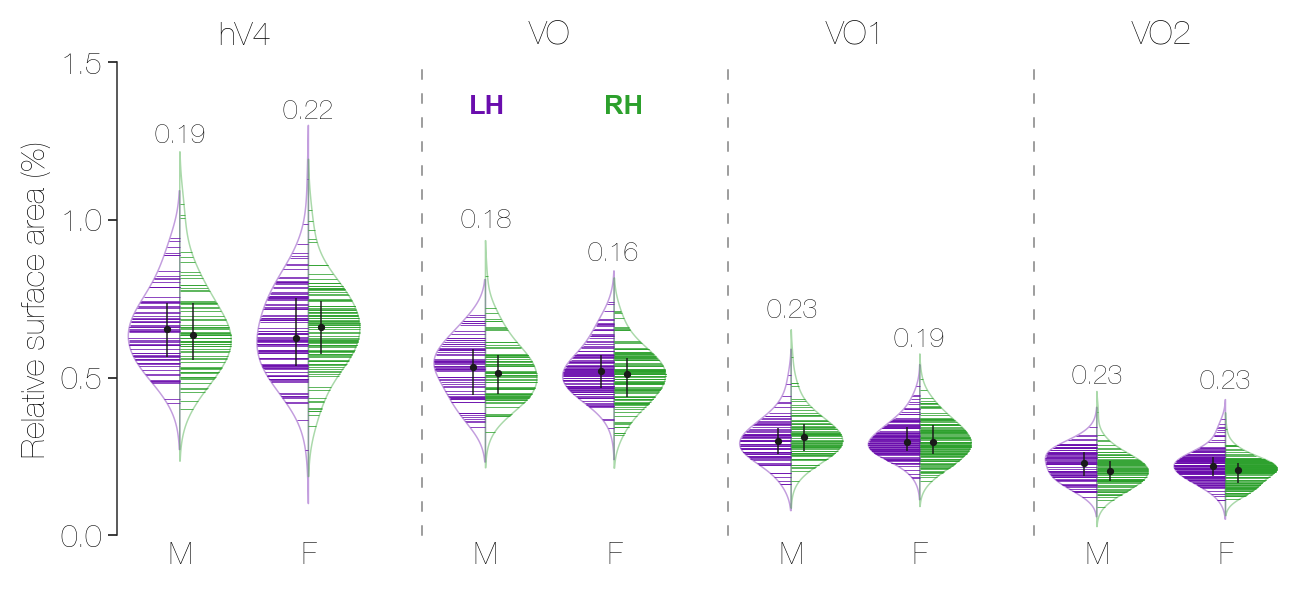

In [308]:
font_scale=1
violin_rc = {'text.color': 'black',
              'axes.labelcolor': 'black',
              'axes.labelpad': 3,
              'axes.titlepad': 6,
              'xtick.major.pad': 2,
              'ytick.major.pad': 2,
              'axes.labelweight': 'light',
              'axes.linewidth':     0.5,
              'xtick.major.width':    0,
              'ytick.major.width':    0.5,
              'xtick.major.size': 0,
              'ytick.major.size': 3,
              'xtick.color': 'black',
              'ytick.color': 'black',
              'xtick.labelcolor': 'black',
              'ytick.labelcolor': 'black',
              'xtick.labelsize': 10*font_scale,
              'ytick.labelsize': 10*font_scale,
              'axes.labelsize': 11*font_scale,
              'axes.titlesize': 11*font_scale,
              'axes.titleweight': 'light',
              'font.family': 'helveticaneue',
              'font.weight': 'light',
              'font.size' : 11*font_scale,
              'figure.dpi': 72*3,
              'savefig.dpi': 72*4,
              }
CoV_ypos=[0.88,0.94,0.7,0.65,0.55,0.48,0.35,0.36]
save_path = os.path.join(fig_dir, 'hv4_dist2.svg')
old_rois = ['V1','V2','V3']
g = vis.plot_violin_surface_area(plot_df.query('ROIs not in @old_rois'), 
                                 x='gender',
                                 order=['M','F'], 
                                 y='percent', 
                                 col='ROIs', 
                                 col_order=roi_list[3:], 
                                 rc=violin_rc, 
                                 CoV=plot_df_all_mean,
                                 CoV_ypos=[0.87,0.92,0.69,0.62,0.5,0.44,0.36,0.35],
                                 #CoV_ypos=[0.69,0.74,0.55,0.5,0.41,0.37,0.32,0.33],
                                 bw=.6,alpha=.4, ylim=(0,1.5),
                                 yticks=(0, 0.5, 1, 1.5),
                                 figsize=(7, 3),
                                 hue_text_loc=(0.37, 0.46),
                                 ylabel='Relative surface area (%)', 
                                 save_path=save_path)

In [293]:
old_df = plot_df.query('ROIs in @roi_list')

summary = old_df.groupby("ROIs")["percent"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

summary["iqr"] = summary["q75"] - summary["q25"]
summary["ROIs"] = pd.Categorical(summary["ROIs"], categories=roi_list, ordered=True)
summary = summary.sort_values("ROIs").reset_index(drop=True)

print(summary)

  ROIs    median       q25       q75       iqr
0   V1  1.335644  1.188184  1.497252  0.309068
1   V2  1.296995  1.154773  1.439165  0.284392
2   V3  1.095380  0.999026  1.180298  0.181272
3  hV4  0.642250  0.558991  0.739191  0.180200
4   VO  0.518286  0.454199  0.573171  0.118972
5  VO1  0.298483  0.261900  0.346726  0.084826
6  VO2  0.211838  0.176658  0.243017  0.066359


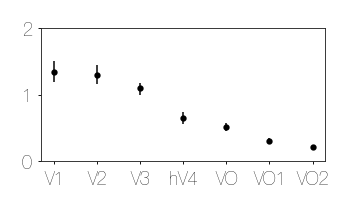

In [309]:
font_scale = 0.6
median_rc = {
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.labelpad': 0,
    'axes.titlepad': 3,
    'axes.labelweight': 'light',
    'axes.linewidth': 0.5*font_scale,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'xtick.major.size': 1.1,
    'ytick.major.size': 1.1,
    'xtick.major.width': 0.5*font_scale,
    'ytick.major.width': 0.5*font_scale,
    'xtick.labelsize': 10*font_scale,
    'ytick.labelsize': 10*font_scale,
    'axes.labelsize': 11*font_scale,
    'axes.titlesize': 11*font_scale,
    'font.family': 'helveticaneue',
    'font.weight': 'light',
    'font.size': 11*font_scale,
    'figure.dpi': 72*3,
    'savefig.dpi': 72*4
}

sns.set_theme(style='ticks', rc=median_rc, font_scale=font_scale)
save_path = os.path.join(fig_dir, 'v1_v3_dist.svg')
fig, ax = plt.subplots(1,1, figsize=(1.7, 0.8))

ax.errorbar(
    x=summary["ROIs"],
    y=summary["median"],
    yerr=[summary["median"] - summary["q25"], 
          summary["q75"] - summary["median"]],
    fmt='o', capsize=None, color="black",
    linewidth=0.5, markersize=1.1
)

ax.set(ylim=(0,2), yticks=[0,1,2])
#ax.margins(x=0.1)


save_path = os.path.join(fig_dir, 'hv4_dist2_inset.svg')
fig.savefig(save_path, bbox_inches='tight', transparent=False)


In [ ]:
grouped = tmp.groupby([x,hue])[y]
            grouped_medians = grouped.median().unstack()  # Compute median for each gender
            # Compute and plot the interquartile range (IQR)
            q1 = grouped.quantile(0.25).unstack()  # 25th percentile (Q1)
            q3 = grouped.quantile(0.75).unstack()  # 75th percentile (Q3)    
            # X-axis positions ('M' at 0, 'F' at 1), LH shifted slightly left, RH slightly right
            x_offsets = {hue_order[0]: -0.1, hue_order[1]: 0.1}  # Small offset to separate LH and RH dots
            for gender, x_pos in zip(order, range(len(order))):
                for hemisphere in hue_order:
                    median_value = grouped_medians.loc[gender, hemisphere]
                    ax.scatter(x_pos + x_offsets[hemisphere], median_value, 
                               color='k', s=2*font_scale, zorder=3)
                    lower = q1.loc[gender, hemisphere]
                    upper = q3.loc[gender, hemisphere]
                    ax.vlines(x_pos + x_offsets[hemisphere], 
                              ymin=lower, ymax=upper, color='k', linewidth=0.5*font_scale)

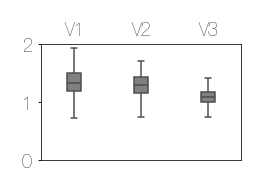

In [159]:
font_scale = 0.6
median_rc = {
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.labelpad': 0,
    'axes.titlepad': 3,
    'axes.labelweight': 'light',
    'axes.linewidth': 0.5*font_scale,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'xtick.major.size': 0,
    'ytick.major.size': 1,
    'xtick.major.width': 0.5*font_scale,
    'ytick.major.width': 0.5*font_scale,
    'xtick.labelsize': 10*font_scale,
    'ytick.labelsize': 10*font_scale,
    'axes.labelsize': 10*font_scale,
    'axes.titlesize': 10*font_scale,
    'font.family': 'helveticaneue',
    'font.weight': 'light',
    'font.size': 10*font_scale,
    'figure.dpi': 72*3,
    'savefig.dpi': 72*4
}

save_path = os.path.join(fig_dir, 'v1_v3_dist.svg')
old_rois = ['V1','V2','V3']

sns.set_theme(style='ticks', rc=median_rc, font_scale=font_scale)
fig, ax = plt.subplots(1,1, figsize=(1.2, 0.7))

sns.pointplot(
    data=plot_df.query('ROIs in @old_rois'),
    width=0.2, linewidth=0.5, x='ROIs', y='percent', fliersize=0, color='gray',
    order=old_rois
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set(ylim=[0,2], yticks=[0,1,2])

# --- changes here ---
# put x ticklabels on top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# remove box lines (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
#ax.spines['top'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
#ax.spines['right'].set_visible(False)
#ax.spines['left'].set_visible(True)

save_path = os.path.join(fig_dir, 'hv4_dist2_inset.svg')
fig.savefig(save_path, bbox_inches='tight', transparent=False)


Text(0, 0.5, '')

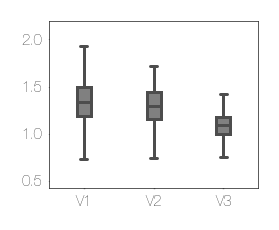

In [101]:
font_scale=0.5

median_rc = {'text.color': 'black',
              'axes.labelcolor': 'black',
              'axes.labelpad': 0,
              'axes.titlepad': 3,
              'xtick.major.pad': 2,
              'ytick.major.pad': 2,
              'axes.labelweight': 'light',
              'axes.linewidth':     0.5*font_scale,
              'xtick.major.size':3,
              'ytick.major.size':3,
              'xtick.major.width':    0.5,
              'ytick.major.width':    0.5*font_scale,
              'xtick.color': 'black',
              'ytick.color': 'black',
              'xtick.labelcolor': 'black',
              'ytick.labelcolor': 'black',
              'xtick.labelsize': 10*font_scale,
              'ytick.labelsize': 10*font_scale,
              'axes.labelsize': 10*font_scale,
              'axes.titlesize': 10*font_scale,
              'font.family': 'helveticaneue',
              'font.weight': 'light',
              'font.size' : 10*font_scale,
              'figure.dpi': 72*3,
              'savefig.dpi': 72*4,
              }
save_path = os.path.join(fig_dir, 'v1_v3_dist.svg')
old_rois = ['V1','V2','V3']

sns.set_theme(style='ticks', rc=median_rc, font_scale=font_scale)
fig, ax = plt.subplots(1,1, figsize=(1.25, 1))
ax.tick_params(axis='both', size=0.2)
sns.boxplot(plot_df.query('ROIs in @old_rois'), width=0.2, 
                          x='ROIs', y='percent', fliersize=0, color='gray', 
                          order=old_rois)
ax.set_xlabel('')
ax.set_ylabel('')

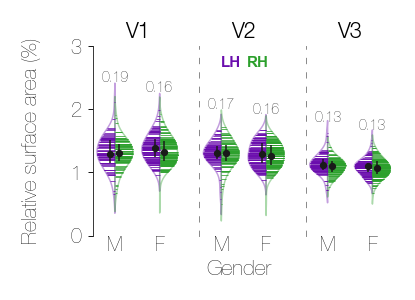

In [41]:
font_scale=0.6

violin_rc = {'text.color': 'black',
              'axes.labelcolor': 'black',
              'axes.labelpad': 10,
              'axes.titlepad': 3,
              'xtick.major.pad': 0,
              'ytick.major.pad': 2,
              'axes.labelweight': 'light',
              'axes.linewidth':     0.5*font_scale,
              'xtick.major.width':    0,
              'ytick.major.width':    0.5*font_scale,
              'xtick.major.size': 0,
              'ytick.major.size': 3*font_scale,
              'xtick.color': 'black',
              'ytick.color': 'black',
              'xtick.labelcolor': 'black',
              'ytick.labelcolor': 'black',
              'xtick.labelsize': 11*font_scale,
              'ytick.labelsize': 11*font_scale,
              'axes.labelsize': 12*font_scale,
              'axes.titlesize': 12*font_scale,
              'font.family': 'helveticaneue',
              'font.weight': 'light',
              'font.size' : 12*font_scale,
              'figure.dpi': 72*3,
              'savefig.dpi': 72*4,
              }
save_path = os.path.join(fig_dir, 'v1_v3_dist.svg')
old_rois = ['V1','V2','V3']
g = vis.plot_violin_surface_area(plot_df.query('ROIs in @old_rois'), 
                                 x='gender',
                                 order=['M','F'], 
                                 y='percent', 
                                 col='ROIs', 
                                 col_order=roi_list[:3], 
                                 rc=violin_rc, 
                                 CoV=plot_df_all_mean,
                                 CoV_ypos=[0.87,0.82,0.73,0.7,0.66,0.62],
                                 bw=.6,alpha=.4, ylim=[0,3],
                                 yticks=[0,1,2,3],
                                 figsize=(1.8,1.2),
                                 hue_text_loc=(0.48, 0.55),
                                 ylabel='Relative surface area (%)', 
                                 save_path=save_path)

# Fig 3. Ventral only: Surface area distributions for each researcher

In [66]:
area_type='mm2'
tmp_cols = [k for k in long_ventral_df.columns if f'_{area_type}' in k]
new_cols = [k.replace(f'_{area_type}','') for k in tmp_cols]
plot_df = long_ventral_df.query('researcher != "mean"')
plot_df = plot_df[['sid','researcher','hemisphere']+tmp_cols]
#plot_df = plot_df.rename(columns=dict(zip(tmp_cols, new_cols)))
sum_long_ventral_df = plot_df.groupby(['sid','researcher']).sum().reset_index().drop(['hemisphere'],axis=1)
sum_long_ventral_df.groupby()

,sid,researcher,hV4_mm2,VO1_mm2,VO2_mm2,cortex_mm2,VO_mm2
0,100610,R1,1475.791992,366.196762,686.297913,207352.960938,1052.494675
1,100610,R2,1612.637268,496.569962,415.652222,207352.960938,912.222183
2,100610,R3,1453.551025,439.006729,553.075165,207352.960938,992.081894
3,100610,R4,1632.040527,530.455170,457.755585,207352.960938,988.210754
4,100610,R5,1363.547333,552.243973,961.899353,207352.960938,1514.143326
...,...,...,...,...,...,...,...
900,995174,R1,1923.181152,852.268036,377.133011,191442.687500,1229.401047
901,995174,R2,2058.958252,762.537964,467.448196,191442.687500,1229.986160
902,995174,R3,1887.770386,747.953674,456.949631,191442.687500,1204.903305
903,995174,R4,1833.340942,900.979614,812.553101,191442.687500,1713.532715


In [45]:
area_type='percent'
tmp_cols = [k for k in long_ventral_df.columns if f'_{area_type}' in k]
new_cols = [k.replace(f'_{area_type}','') for k in tmp_cols]
plot_df = long_ventral_df.query('researcher != "mean"')
plot_df = plot_df[['sid','researcher','hemisphere']+tmp_cols]
plot_df = plot_df.rename(columns=dict(zip(tmp_cols, new_cols)))
plot_df = pd.melt(plot_df, 
                  id_vars=['researcher','sid','hemisphere'], 
                  var_name='ROI', value_name=area_type)
plot_df = plot_df.replace({'hemisphere': {'lh': 'LH', 'rh': 'RH'}})
replace_dict = dict(zip(ventral_raters, [f'Researcher {i}' for i in np.arange(1,6)]))


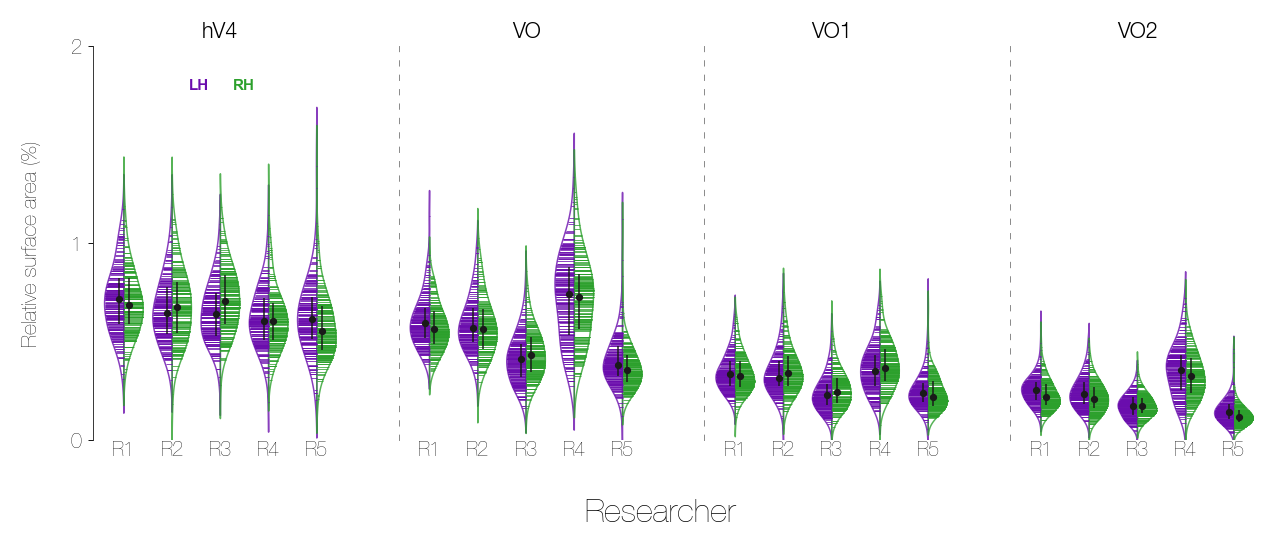

In [48]:
fig, axes = vis.plot_violin_surface_area(plot_df, 
                                         x='researcher', y='percent', order=['R1','R2','R3','R4','R5'], 
                                         col='ROI', col_order=['hV4', 'VO', 'VO1', 'VO2'],
                                         hue='hemisphere', bw=.5, iqr=True, rc=violin_rc,
                                         hue_order=['LH', 'RH'], alpha=.8, 
                                         ylim=[0, 2], yticks=[0,1,2], hue_text_loc=(0.195, 0.225),
                                         ylabel='Relative surface area (%)', 
                                         save_path=os.path.join(fig_dir, 'researcher_dist.png'))